# Pipeline Load Test Results - Throughput Analysis

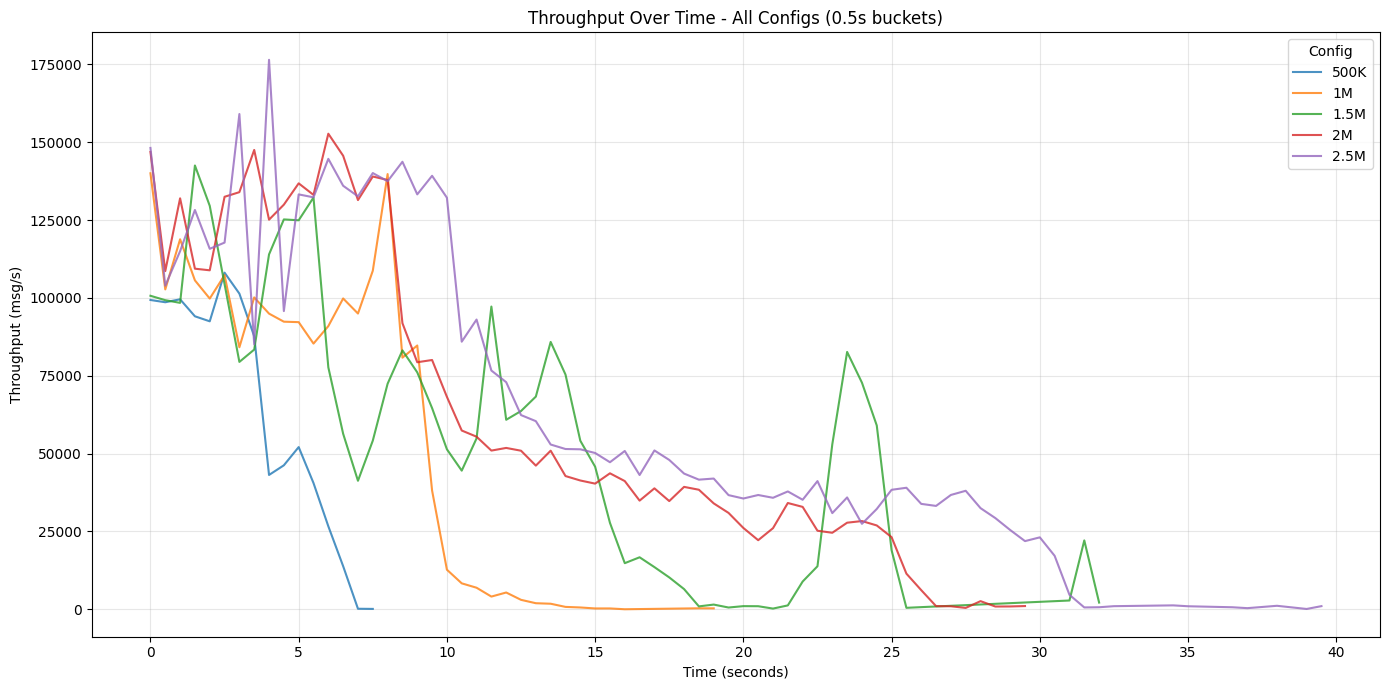

In [1]:
import csv
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import os

# Define test configs and their CSV paths
configs = {
    "500K": "500K/metrics.csv",
    "1M": "1M/metrics.csv",
    "1.5M": "1_5M/metrics.csv",
    "2M": "2M/metrics.csv",
    "2.5M": "2_5M/metrics.csv",
}

BUCKET_SIZE = 0.5

def load_throughput(csv_path):
    """Read a metrics CSV and return (time_buckets, throughput) arrays."""
    with open(csv_path) as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    times = [datetime.fromisoformat(r["Timestamp"]) for r in rows]
    start = min(times)

    buckets = defaultdict(int)
    for t in times:
        bucket = (t - start).total_seconds() // BUCKET_SIZE * BUCKET_SIZE
        buckets[bucket] += 1

    x = sorted(buckets.keys())
    y = [buckets[b] / BUCKET_SIZE for b in x]
    return x, y

# Plot all configs on one graph
plt.figure(figsize=(14, 7))

for label, path in configs.items():
    full_path = os.path.join(os.getcwd(), path)
    if not os.path.exists(full_path):
        print(f"Skipping {label}: {full_path} not found")
        continue
    x, y = load_throughput(full_path)
    plt.plot(x, y, label=label, linewidth=1.5, alpha=0.8)

plt.xlabel("Time (seconds)")
plt.ylabel("Throughput (msg/s)")
plt.title(f"Throughput Over Time - All Configs ({BUCKET_SIZE}s buckets)")
plt.legend(title="Config")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("throughput-comparison.png", dpi=150)
plt.show()

C:\Users\supri\AppData\Local\Temp\ipykernel_59184\1848031874.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(all_latencies.values(), labels=all_latencies.keys(), showfliers=False)


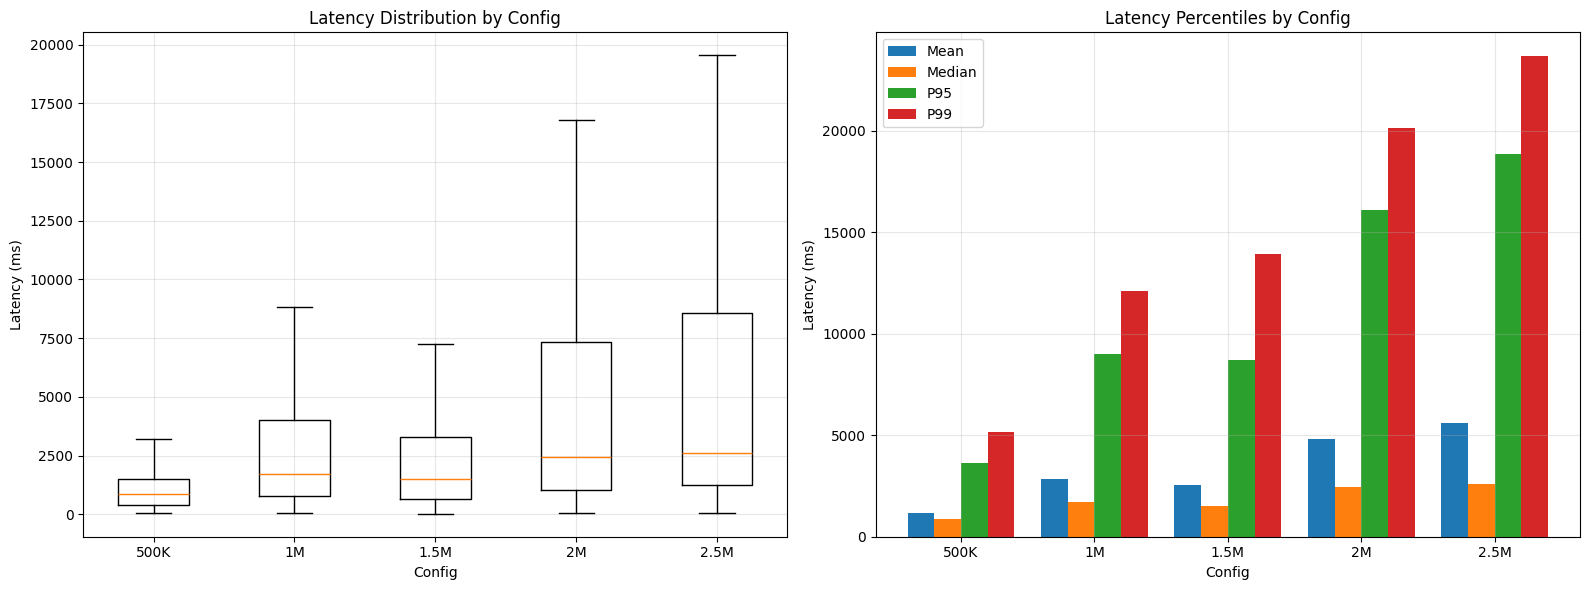

Config        Count     Mean   Median      P95      P99
----------------------------------------------------------
500K        502,000     1167      852     3615     5150
1M        1,004,000     2828     1718     8991    12129
1.5M      1,497,559     2553     1517     8688    13936
2M        1,858,817     4802     2438    16104    20115
2.5M      2,270,446     5597     2617    18833    23666


In [2]:
# Latency distribution comparison (box plot)
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

all_latencies = {}
summary = []

for label, path in configs.items():
    full_path = os.path.join(os.getcwd(), path)
    if not os.path.exists(full_path):
        continue
    with open(full_path) as f:
        reader = csv.DictReader(f)
        latencies = [int(r["Latency"]) for r in reader]
    all_latencies[label] = latencies
    arr = np.array(latencies)
    summary.append({
        "config": label,
        "count": len(arr),
        "mean": np.mean(arr),
        "median": np.median(arr),
        "p95": np.percentile(arr, 95),
        "p99": np.percentile(arr, 99),
    })

# Box plot
ax1.boxplot(all_latencies.values(), labels=all_latencies.keys(), showfliers=False)
ax1.set_xlabel("Config")
ax1.set_ylabel("Latency (ms)")
ax1.set_title("Latency Distribution by Config")
ax1.grid(True, alpha=0.3)

# Bar chart of mean/median/p95/p99
x_pos = np.arange(len(summary))
width = 0.2
ax2.bar(x_pos - 1.5*width, [s["mean"] for s in summary], width, label="Mean")
ax2.bar(x_pos - 0.5*width, [s["median"] for s in summary], width, label="Median")
ax2.bar(x_pos + 0.5*width, [s["p95"] for s in summary], width, label="P95")
ax2.bar(x_pos + 1.5*width, [s["p99"] for s in summary], width, label="P99")
ax2.set_xticks(x_pos)
ax2.set_xticklabels([s["config"] for s in summary])
ax2.set_xlabel("Config")
ax2.set_ylabel("Latency (ms)")
ax2.set_title("Latency Percentiles by Config")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("latency-comparison.png", dpi=150)
plt.show()

# Print summary table
print(f"{'Config':<8} {'Count':>10} {'Mean':>8} {'Median':>8} {'P95':>8} {'P99':>8}")
print("-" * 58)
for s in summary:
    print(f"{s['config']:<8} {s['count']:>10,} {s['mean']:>8.0f} {s['median']:>8.0f} {s['p95']:>8.0f} {s['p99']:>8.0f}")

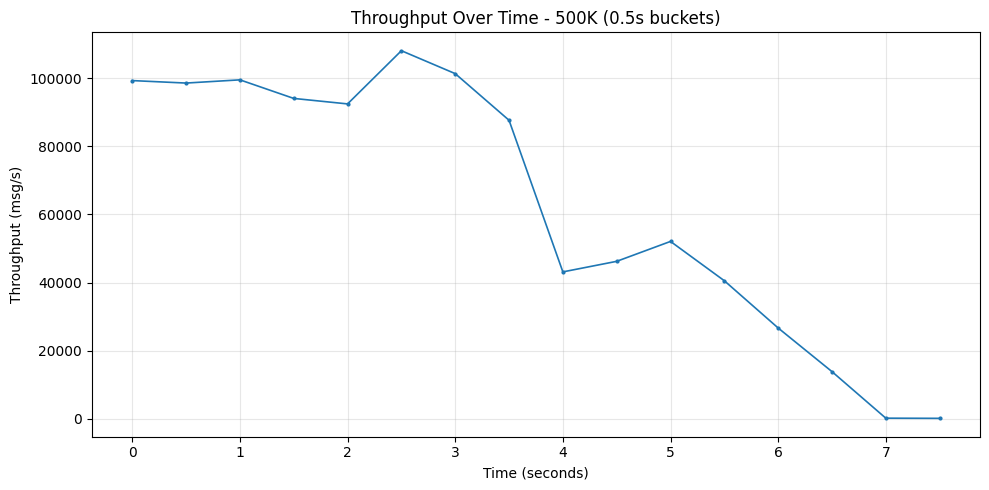

Saved 500K throughput to d:\northeastern-workspace\distributed-systems\chat-flow\results\500K/throughput.png


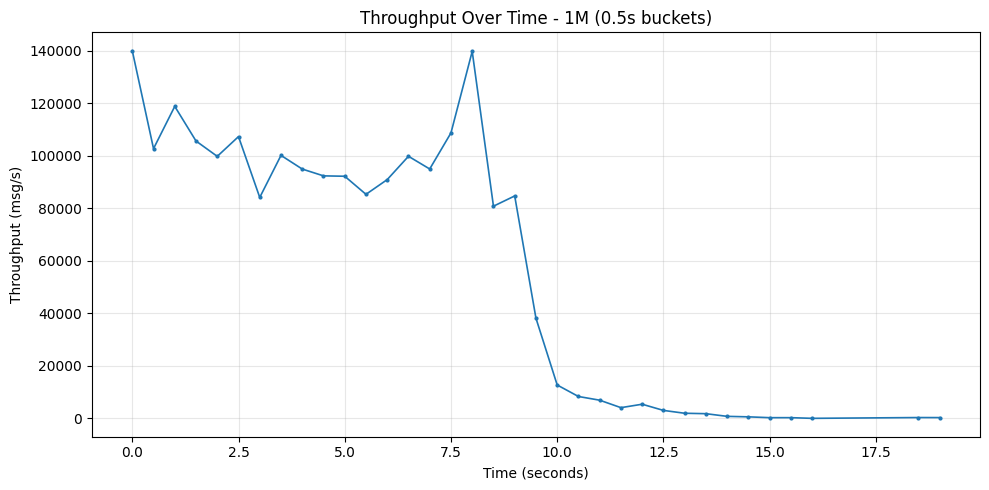

Saved 1M throughput to d:\northeastern-workspace\distributed-systems\chat-flow\results\1M/throughput.png


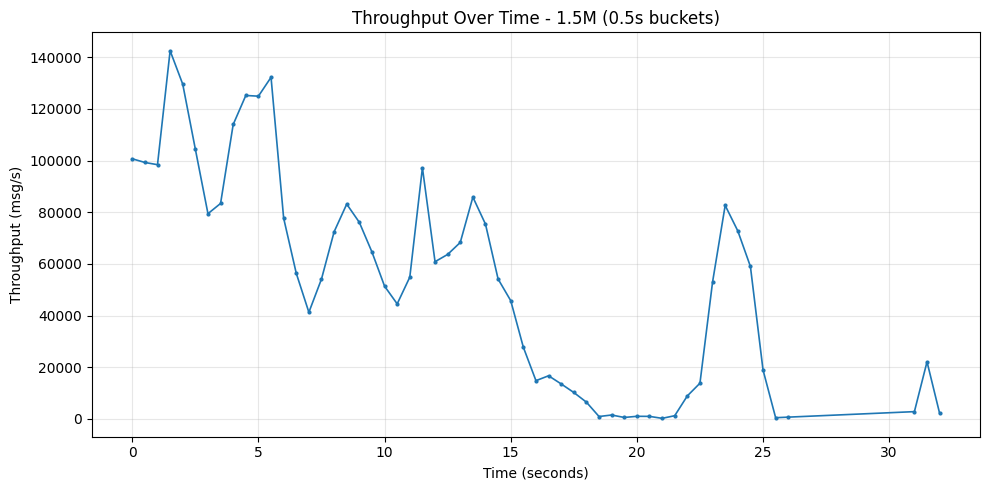

Saved 1.5M throughput to d:\northeastern-workspace\distributed-systems\chat-flow\results\1_5M/throughput.png


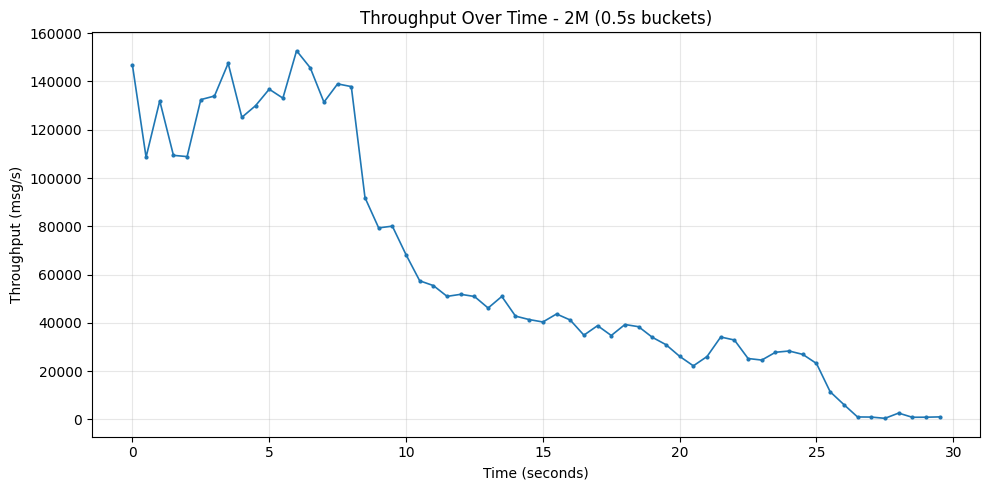

Saved 2M throughput to d:\northeastern-workspace\distributed-systems\chat-flow\results\2M/throughput.png


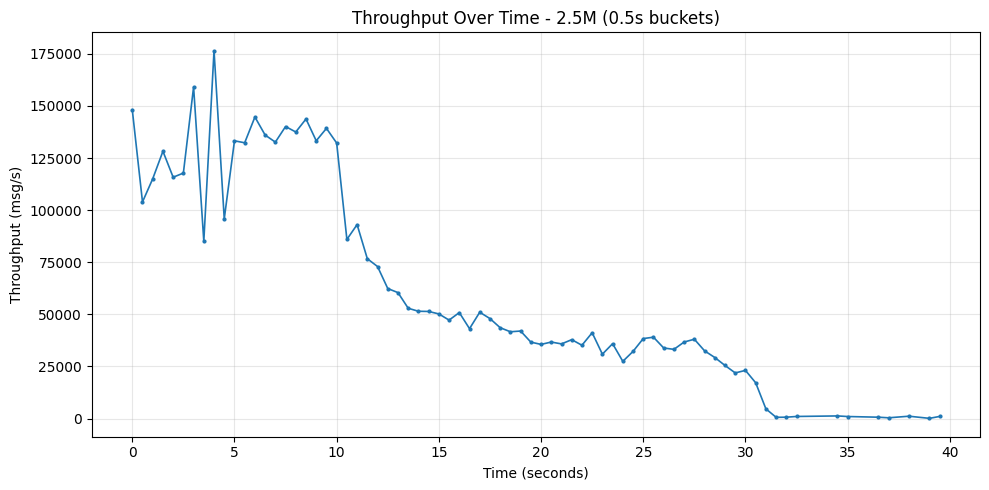

Saved 2.5M throughput to d:\northeastern-workspace\distributed-systems\chat-flow\results\2_5M/throughput.png


In [3]:
# Individual throughput graphs per config
for label, path in configs.items():
    full_path = os.path.join(os.getcwd(), path)
    if not os.path.exists(full_path):
        print(f"Skipping {label}: {full_path} not found")
        continue

    x, y = load_throughput(full_path)

    plt.figure(figsize=(10, 5))
    plt.plot(x, y, marker="o", markersize=2, linewidth=1.2)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Throughput (msg/s)")
    plt.title(f"Throughput Over Time - {label} ({BUCKET_SIZE}s buckets)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save to the config's own folder
    config_dir = os.path.dirname(full_path)
    plt.savefig(os.path.join(config_dir, "throughput.png"), dpi=150)
    plt.show()
    print(f"Saved {label} throughput to {config_dir}/throughput.png")